### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 179.7       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 1515*1000
Fy_0 = 0.7*Fx_0
LTD = 209

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
# Ar=np.pi*((d0/2)**2-(dI/2)**2)
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 34 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])                ### !!! ### !!! ### !!! ###
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.46641422, 0.12125253, 0.38827326, 0.55804295, 0.59274069,
       0.38828357, 0.36794184, 0.50124397, 0.80309706, 0.53325041,
       0.61205849, 0.68354175, 0.73460218, 0.81827913, 0.54237518,
       0.89190865, 0.96397685, 0.43154912, 0.40911775, 0.75602068])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 12)

coefs = [1, 1, 1, 1, 1, 1]
vessel_motion_calibration_coefficient = 5e2 #  to control the force from the vessel   ### !!! ### !!! ### !!! ###

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.91534547,  0.        ,  0.3596589 ],
        [ 0.        ,  1.        , -0.44968642],
        [-0.40266943,  0.        ,  0.81757422]],

       [[ 0.706373  ,  0.        ,  0.70264278],
        [ 0.        ,  1.        , -0.12095564],
        [-0.7078398 ,  0.        ,  0.70118675]],

       [[ 0.79099211,  0.        ,  0.56628455],
        [ 0.        ,  1.        , -0.37859077],
        [-0.61182635,  0.        ,  0.73211395]],

       [[ 0.63357289,  0.        ,  0.65630991],
        [ 0.        ,  1.        , -0.52952706],
        [-0.773683  ,  0.        ,  0.53745548]],

       [[ 0.97752908,  0.        ,  0.17484071],
        [ 0.        ,  1.        , -0.55863628],
        [-0.2108006 ,  0.        ,  0.81077508]],

       [[ 0.80228159,  0.        ,  0.55250928],
        [ 0.        ,  1.        , -0.37860031],
        [-0.59694576,  0.        ,  0.74255996]],

       [[ 0.84452287,  0.        ,  0.49967698],
        [ 0.        ,  1.        , -0.35969578],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-0.35794218,  0.        ,  0.60145365],
        [ 0.        ,  0.        , -0.61810054],
        [-0.8136718 ,  0.        , -0.60455621]],

       [[-0.32446238,  0.        ,  0.25853072],
        [ 0.        ,  0.        , -0.72906266],
        [-0.32379002,  0.        , -0.38483184]],

       [[-0.53522032,  0.        ,  0.49117965],
        [ 0.        ,  0.        , -0.5964482 ],
        [-0.69195295,  0.        , -0.68835901]],

       [[-0.19986954,  0.        , -0.21106052],
        [ 0.        ,  0.        , -0.72450906],
        [-0.16367417,  0.        , -0.45608624]],

       [[-0.04025776,  0.        ,  0.05380352],
        [ 0.        ,  0.        , -0.71160713],
        [-0.18668416,  0.        , -0.5019106 ]],

       [[-0.06436011,  0.        , -0.03350475],
        [ 0.        ,  0.        , -0.46508347],
        [-0.08649853,  0.        , -0.21219708]],

       [[-0.40278001,  0.        ,  0.5044469 ],
        [ 0.        ,  0.        , -0.42738608],
        

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.94447778,  0.50002207,  0.42840631],
       [ 0.6320893 ,  0.43888173, -0.40682125],
       [ 0.85172742,  0.64614665,  0.04787932],
       [ 0.60650839,  0.20557914, -0.60724027],
       [ 0.84430719,  0.17301449, -0.1547918 ],
       [ 0.48821408,  0.04951787, -0.18561721],
       [ 0.77935499,  0.46956624,  0.37373065],
       [ 0.51887987,  0.10327856,  0.24560995],
       [ 0.58087424,  0.19909694,  0.55124939],
       [ 0.2574271 ,  0.66214101,  0.40463043],
       [ 0.15930873,  0.79904395, -0.13920021],
       [ 0.38931146, -0.02173143,  0.07844051],
       [ 0.93800421, -0.37690189, -0.12729865],
       [ 1.06629106, -0.45374923,  0.14716449],
       [ 0.98614485,  0.3207483 ,  0.09364328],
       [ 0.92120561,  0.21110969,  0.24293413],
       [ 0.36990192, -0.46384181,  0.27823016],
       [ 0.88699215,  0.322746  , -0.47202905],
       [ 0.89927252,  0.44952008,  0.40709075],
       [ 0.37432559,  0.02062407,  0.49133826]])

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 1.36878731, -0.47112302, -0.70045587],
       [ 0.46685874,  0.08532808, -0.77320845],
       [ 0.54918795,  0.55879951, -1.27240347],
       [ 0.26472732,  0.68786127, -0.25026707],
       [ 0.1651884 ,  0.03037695,  0.62400311],
       [ 0.20872166,  0.85008612, -0.14960713],
       [ 0.70331965, -0.33830056, -0.47511788],
       [ 0.53031071,  0.3184193 , -0.26005308],
       [ 0.89229182, -0.05988062, -0.22241864],
       [ 0.77243786,  0.31148806,  0.35155502],
       [ 0.54802854,  0.84874406, -0.51230459],
       [ 0.80951036,  0.42497726, -0.39456911],
       [ 0.5330843 , -0.44917711, -0.6885007 ],
       [ 0.63293434, -0.72371624, -0.23160263],
       [ 0.19516052, -0.13993931, -0.06071759],
       [ 0.36722843, -0.67248589, -0.30665369],
       [ 0.28973304, -0.19137512,  0.19371921],
       [ 0.24349619, -0.12399961, -0.64756253],
       [ 0.70289381, -0.54011877, -0.47575265],
       [ 0.95182831,  0.06984116, -0.48529407]])

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.29059815, 0.23563676, 0.05766953],
       [0.12515455, 0.59965908, 0.73292749],
       [0.52170306, 0.28508226, 0.7459131 ],
       [0.99166484, 0.06305113, 0.40652077],
       [0.93259093, 0.11837157, 0.99187718],
       [0.78084844, 0.30134185, 0.28966148],
       [0.25576943, 0.57698138, 0.98348241],
       [0.23765486, 0.15280829, 0.96326905],
       [0.73700937, 0.41344169, 0.34235322],
       [0.59898619, 0.51614076, 0.5270631 ],
       [0.34173404, 0.02966656, 0.23730904],
       [0.51642601, 0.69984497, 0.99040852],
       [0.61862928, 0.69088514, 0.40640686],
       [0.97242714, 0.43854419, 0.92861588],
       [0.86710519, 0.71265838, 0.2926138 ],
       [0.77380072, 0.33876763, 0.71595302],
       [0.2056886 , 0.62046092, 0.39465801],
       [0.43847946, 0.21699523, 0.72409779],
       [0.7465263 , 0.81054434, 0.32616031],
       [0.8699892 , 0.96261472, 0.83065506]])

In [44]:
theta(φ,θ,ψ)

array([[0.46641422, 0.41443129, 0.56114653],
       [0.12125253, 0.78643535, 0.21010043],
       [0.38827326, 0.65836748, 0.44367869],
       [0.55804295, 0.88463376, 0.19019317],
       [0.59274069, 0.21239389, 0.77615452],
       [0.38828357, 0.63968875, 0.19865021],
       [0.36794184, 0.56512276, 0.02473591],
       [0.50124397, 0.87919872, 0.73872071],
       [0.80309706, 0.25521985, 0.18819785],
       [0.53325041, 0.21870513, 0.46701789],
       [0.61205849, 0.74543114, 0.08416039],
       [0.68354175, 0.63153527, 0.20443078],
       [0.73460218, 0.70840444, 0.45665736],
       [0.81827913, 0.35214258, 0.90505648],
       [0.54237518, 0.13964155, 0.76431932],
       [0.89190865, 0.07648777, 0.52984899],
       [0.96397685, 0.61816656, 0.52056381],
       [0.43154912, 0.73735529, 0.63352237],
       [0.40911775, 0.33245267, 0.11562528],
       [0.75602068, 0.55573578, 0.57049225]])

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.29546688,  0.21911298, -0.01411891],
       [ 0.51371904,  0.50816915,  0.52968737],
       [ 0.68251787, -0.08664903,  0.47386248],
       [ 1.00371315, -0.27718167,  0.15956144],
       [ 0.99584931, -0.67827065,  0.47664611],
       [ 0.80673008,  0.09745425, -0.03527726],
       [ 0.73339744,  0.32817028,  0.6579338 ],
       [ 0.37738773, -0.07396842,  0.88911075],
       [ 0.77676111,  0.18335416, -0.06395662],
       [ 0.73579156,  0.21897971,  0.08298227],
       [ 0.34821575, -0.04986077,  0.21335167],
       [ 0.94976557,  0.21080561,  0.32617592],
       [ 0.68774312,  0.45520207, -0.13903814],
       [ 1.10252062, -0.32872964,  0.06067239],
       [ 0.77986877,  0.48955233, -0.42370112],
       [ 0.90000279, -0.16158242,  0.22583418],
       [ 0.39197177,  0.53985546,  0.19473991],
       [ 0.56934416, -0.09043009,  0.54581934],
       [ 0.68793205,  0.58905116, -0.37599511],
       [ 0.93668066,  0.32772681, -0.40794083]])

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.87133352, -0.33380141,  0.3596589 ],
        [ 0.47531567,  0.75621236, -0.44968642],
        [-0.12187254,  0.56277836,  0.81757422]],

       [[ 0.708696  , -0.06358534,  0.70264278],
        [ 0.20702687,  0.97082934, -0.12095564],
        [-0.67445522,  0.23118672,  0.70118675]],

       [[ 0.81383858, -0.13034022,  0.56628455],
        [ 0.39731219,  0.83594979, -0.37859077],
        [-0.42403985,  0.53310353,  0.73211395]],

       [[ 0.69959872,  0.28252246,  0.65630991],
        [ 0.1603686 ,  0.8329964 , -0.52952706],
        [-0.69630708,  0.47570795,  0.53745548]],

       [[ 0.78007343, -0.60076299,  0.17484071],
        [ 0.58103716,  0.59187949, -0.55863628],
        [ 0.23212337,  0.53736627,  0.81077508]],

       [[ 0.83110482,  0.06323195,  0.55250928],
        [ 0.18265587,  0.90735805, -0.37860031],
        [-0.52526338,  0.4155756 ,  0.74255996]],

       [[ 0.84902876,  0.17167726,  0.49967698],
        [ 0.02307798,  0.93278419, -0.35969578],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[-5.45023354e-02,  4.24830471e-02,  1.01053529e-01],
       [ 5.20899929e-01, -1.63277673e-01,  4.46400789e-02],
       [ 3.40913494e-01, -3.70967359e-01, -9.66592513e-02],
       [ 3.39457414e-01, -5.21255389e-01, -7.47224415e-01],
       [-2.79096583e-01, -2.38976052e-01,  2.90934119e-01],
       [ 1.88903478e-01, -1.87830998e-01, -3.13827175e-01],
       [ 6.49479835e-01, -3.63169897e-01,  4.41545056e-02],
       [ 5.00833682e-01, -7.82155893e-01,  5.13192624e-04],
       [ 7.25553767e-02, -3.33553859e-01,  2.46619786e-01],
       [-1.52773365e-01, -1.54493409e-01,  3.24912677e-01],
       [ 1.76237134e-01, -2.42389433e-01, -2.23486504e-01],
       [ 6.90501245e-01, -7.81428244e-01,  1.92128621e-01],
       [ 3.15911065e-01, -4.52793734e-01,  2.88864777e-01],
       [-4.17358026e-01, -6.21197150e-01,  7.30412528e-01],
       [-4.82765824e-01,  3.12822841e-01,  6.68707117e-01],
       [-3.29765906e-01, -4.50940702e-01,  5.69782093e-01],
       [ 2.71726444e-01, -4.43085520e-01

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[-0.02134072, -0.2264383 ,  0.18497259],
       [ 0.11153147, -0.0415551 ,  0.09117985],
       [ 0.16012362, -0.21385298,  0.1772051 ],
       [ 0.44060807, -0.27487663, -0.01426488],
       [-0.27879889, -0.25610639,  0.28299891],
       [ 0.16604349, -0.11640756,  0.05030274],
       [ 0.11409525, -0.07331945, -0.02207009],
       [ 0.36343007, -0.59118095,  0.45700411],
       [ 0.0420166 , -0.2137171 ,  0.11052962],
       [-0.06929094, -0.13619975,  0.14290032],
       [ 0.33040404, -0.26490072, -0.05657479],
       [ 0.27677611, -0.32031337,  0.06408606],
       [ 0.33999214, -0.51748951,  0.25584368],
       [-0.38430761, -0.64407243,  0.59805795],
       [-0.27479016, -0.16950186,  0.22596429],
       [-0.19812567, -0.24957591,  0.36953831],
       [ 0.29498996, -0.80384014,  0.40829501],
       [ 0.19910367, -0.38886787,  0.31697502],
       [ 0.04417447, -0.06231895,  0.02288029],
       [ 0.11946454, -0.52628447,  0.35435618]])

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
#     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[-5.45023354e+07,  4.24830471e+07,  1.01053529e+08],
       [ 5.20899929e+08, -1.63277673e+08,  4.46400789e+07],
       [ 3.40913494e+08, -3.70967359e+08, -9.66592513e+07],
       [ 3.39457414e+08, -5.21255389e+08, -7.47224415e+08],
       [-2.79096583e+08, -2.38976052e+08,  2.90934119e+08],
       [ 1.88903478e+08, -1.87830998e+08, -3.13827175e+08],
       [ 6.49479835e+08, -3.63169897e+08,  4.41545056e+07],
       [ 5.00833682e+08, -7.82155893e+08,  5.13192624e+05],
       [ 7.25553767e+07, -3.33553859e+08,  2.46619786e+08],
       [-1.52773365e+08, -1.54493409e+08,  3.24912677e+08],
       [ 1.76237134e+08, -2.42389433e+08, -2.23486504e+08],
       [ 6.90501245e+08, -7.81428244e+08,  1.92128621e+08],
       [ 3.15911065e+08, -4.52793734e+08,  2.88864777e+08],
       [-4.17358026e+08, -6.21197150e+08,  7.30412528e+08],
       [-4.82765824e+08,  3.12822841e+08,  6.68707117e+08],
       [-3.29765906e+08, -4.50940702e+08,  5.69782093e+08],
       [ 2.71726444e+08, -4.43085520e+08

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[ 4.86834504e+06, -7.83059560e+07,  3.55456343e+07],
       [ 4.40124203e+07,  2.16179020e+07, -4.34505188e+08],
       [-1.50277861e+07,  8.37222579e+07, -3.74319058e+08],
       [-7.57533400e+08,  2.45601391e+08, -5.15469476e+08],
       [ 5.61714461e+07, -3.48812801e+08, -2.32632211e+08],
       [-1.92978446e+08,  1.16285859e+08, -1.85759530e+08],
       [-3.99202909e+07, -1.29580060e+08, -4.78595625e+08],
       [ 2.14689403e+07,  1.31546895e+07, -9.02878407e+08],
       [ 4.10321765e+06, -2.05316250e+08, -2.78897890e+08],
       [ 3.67044331e+07, -2.39786936e+08, -9.67584332e+07],
       [-2.44147295e+08,  4.67070312e+07, -2.43187438e+08],
       [-1.18847015e+08, -3.14293215e+08, -8.51167213e+08],
       [ 1.63270915e+07, -2.94525989e+08, -4.79523439e+08],
       [-3.99862545e+07, -8.41380996e+08, -7.38421153e+08],
       [-3.49612629e+08, -6.96600688e+08,  7.34724903e+07],
       [-7.25184791e+07, -6.08113289e+08, -5.23247675e+08],
       [-3.45990941e+07, -6.17528521e+08

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 6287514.89463875,  1620913.13854638,  2709681.87394887],
       [ 2332750.68713617,  7610225.211733  ,   614922.70766648],
       [ 5583694.68937883,  4903948.19931549,   872675.43283022],
       [ 4783865.4985565 ,  7839213.34272881, -3295279.88496553],
       [ 7151246.69368276, -2211941.84039142,  5043366.48827292],
       [ 4212688.45425444,  5644797.20483405,  -842745.34775126],
       [ 3230952.60255485,  5562253.55740717, -1775481.58575904],
       [ 8186678.47182002,  5242309.69285163,   271044.54550862],
       [ 8100792.62317614,  1198095.37735104,  -762820.88373989],
       [ 6078065.73656054,  -186964.75840271,  2768995.4741247 ],
       [ 4964600.72428844,  6970764.90209433, -3645377.85450531],
       [ 6452796.67330547,  5024284.28867195, -2756208.23399257],
       [ 7783434.71482998,  4023106.69374905, -2205999.83161909],
       [ 9814226.49588563, -3085221.60611155,  2983951.17847533],
       [ 6282121.58915146, -2548784.85186286,  5727637.14636976],
       [ 9

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[ 1.16415322e-10, -3.40038409e-10, -1.16415322e-10],
       [ 5.82076609e-11, -6.81572998e-12,  0.00000000e+00],
       [-5.82076609e-11,  5.59440421e-11,  0.00000000e+00],
       [ 4.65661287e-10, -5.73116770e-10, -4.65661287e-10],
       [ 0.00000000e+00, -1.13747945e-10,  0.00000000e+00],
       [ 4.65661287e-10, -4.03082643e-10,  0.00000000e+00],
       [-2.32830644e-10,  1.43031328e-10,  2.32830644e-10],
       [ 0.00000000e+00,  2.52048668e-11,  0.00000000e+00],
       [-1.45519152e-11,  9.49553987e-12, -2.32830644e-10],
       [ 2.91038305e-11,  4.89549925e-10, -4.36557457e-11],
       [-9.31322575e-10, -3.46365035e-10, -1.39698386e-09],
       [ 0.00000000e+00, -2.73657129e-10,  0.00000000e+00],
       [ 5.82076609e-10, -1.28016960e-09, -4.65661287e-10],
       [ 0.00000000e+00,  9.37433045e-10,  1.39698386e-09],
       [-6.98491931e-10, -7.01856385e-10,  4.65661287e-10],
       [-2.32830644e-10, -3.23321981e-10,  4.65661287e-10],
       [-1.16415322e-10,  1.04483287e-09

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[3.01825070e+00, 2.48450142e+02, 1.58957338e+02],
       [2.34976526e+02, 2.23250690e+01, 1.63361208e+02],
       [1.92400280e+02, 1.73699397e+02, 4.21895755e+02],
       [1.20709325e+02, 2.75358105e+00, 3.17362332e+02],
       [4.39526718e+01, 5.04716464e+01, 5.31976758e+00],
       [1.88127810e+02, 2.67383610e+02, 4.06776463e+02],
       [1.98209719e+02, 3.75190352e+02, 2.16497366e+01],
       [2.24518198e+02, 1.30291979e+02, 5.00765651e+01],
       [2.73592406e+02, 1.04703689e+02, 1.09467876e+02],
       [9.20963438e+01, 1.84316097e+02, 1.28072975e+02],
       [3.14806170e+01, 1.24390078e+02, 1.11413872e+01],
       [1.13861840e+02, 4.44148384e+02, 3.04352446e+02],
       [1.35895660e+02, 8.10293417e+00, 1.20108612e+02],
       [2.51079256e+02, 2.44521390e+02, 2.77469405e+02],
       [5.77864911e+01, 1.79356719e+01, 1.47223406e+01],
       [7.88734655e+01, 1.71771566e+02, 3.82066374e+01],
       [7.16220417e+01, 9.17795529e+01, 4.79939950e+01],
       [3.41683809e-01, 4.26459

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [63]:
sigma(x,y,z)

array([[ 5845.36330569,  5845.36330569,  7242.37690362],
       [ 5845.36330569,  5845.36330569, 23600.13937917],
       [ 5845.36330569,  5845.36330569, 23914.70887139],
       [ 5845.36330569,  5845.36330569, 15693.11127275],
       [ 5845.36330569,  5845.36330569, 29873.0568785 ],
       [ 5845.36330569,  5845.36330569, 12862.25768137],
       [ 5845.36330569,  5845.36330569, 29669.69810888],
       [ 5845.36330569,  5845.36330569, 29180.04025661],
       [ 5845.36330569,  5845.36330569, 14138.68680543],
       [ 5845.36330569,  5845.36330569, 18613.18464702],
       [ 5845.36330569,  5845.36330569, 11594.04770601],
       [ 5845.36330569,  5845.36330569, 29837.47952086],
       [ 5845.36330569,  5845.36330569, 15690.35189196],
       [ 5845.36330569,  5845.36330569, 28340.58590914],
       [ 5845.36330569,  5845.36330569, 12933.7759586 ],
       [ 5845.36330569,  5845.36330569, 23188.94182997],
       [ 5845.36330569,  5845.36330569, 15405.74224075],
       [ 5845.36330569,  5845.3

In [64]:
def ne_hat(x,y,z,dx,dy,dz):
    return fg_e.T - fD(dx,dy,dz) # - sigma(x,y,z).T

In [65]:
ne_hat(x,y,z,dx,dy,dz).T

array([[-3.01825070e+00, -2.48450142e+02, -4.34128490e+02],
       [-2.34976526e+02, -2.23250690e+01, -4.38532360e+02],
       [-1.92400280e+02, -1.73699397e+02, -6.97066906e+02],
       [-1.20709325e+02, -2.75358105e+00, -5.92533484e+02],
       [-4.39526718e+01, -5.04716464e+01, -2.80490919e+02],
       [-1.88127810e+02, -2.67383610e+02, -6.81947614e+02],
       [-1.98209719e+02, -3.75190352e+02, -2.96820888e+02],
       [-2.24518198e+02, -1.30291979e+02, -3.25247717e+02],
       [-2.73592406e+02, -1.04703689e+02, -3.84639028e+02],
       [-9.20963438e+01, -1.84316097e+02, -4.03244127e+02],
       [-3.14806170e+01, -1.24390078e+02, -2.86312539e+02],
       [-1.13861840e+02, -4.44148384e+02, -5.79523597e+02],
       [-1.35895660e+02, -8.10293417e+00, -3.95279764e+02],
       [-2.51079256e+02, -2.44521390e+02, -5.52640557e+02],
       [-5.77864911e+01, -1.79356719e+01, -2.89893492e+02],
       [-7.88734655e+01, -1.71771566e+02, -3.13377789e+02],
       [-7.16220417e+01, -9.17795529e+01

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', RET, Jrho0, RET)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[112.9354521 , -16.17337201,  29.40478409],
        [-16.17337201, 120.22178738, -36.76520218],
        [ 29.40478409, -36.76520218, 166.84276052]],

       [[149.37068816,  -8.49886063,  49.26838068],
        [ -8.49886063, 101.46302664,  -8.48124902],
        [ 49.26838068,  -8.48124902, 149.1662852 ]],

       [[132.06781919, -21.43901046,  41.45848191],
        [-21.43901046, 114.3330972 , -27.7171585 ],
        [ 41.45848191, -27.7171585 , 153.59908361]],

       [[143.07426954, -34.75338593,  35.27373561],
        [-34.75338593, 128.03989125, -28.45972224],
        [ 35.27373561, -28.45972224, 128.88583921]],

       [[103.05692723,  -9.7672362 ,  14.17564871],
        [ -9.7672362 , 131.20744974, -45.29283775],
        [ 14.17564871, -45.29283775, 165.73562303]],

       [[130.52665026, -20.9180185 ,  41.02712702],
        [-20.9180185 , 114.3338196 , -28.11334342],
        [ 41.02712702, -28.11334342, 155.13953014]],

       [[124.96770824, -17.97317025,  39.37447803],


### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 11.027354079515861,
 22.056523745356273,
 33.08932488275457,
 44.127573974810836,
 55.17308840154847,
 66.22768673911834,
 77.29318905920005,
 88.3714172286495,
 99.46419520944222,
 110.5733493589617,
 121.70070873068227,
 132.84810537529617,
 144.01737464233418,
 155.21035548232967,
 166.42889074957577,
 177.6748275055255,
 188.95001732288486,
 200.2563165904489,
 211.59558681873108]

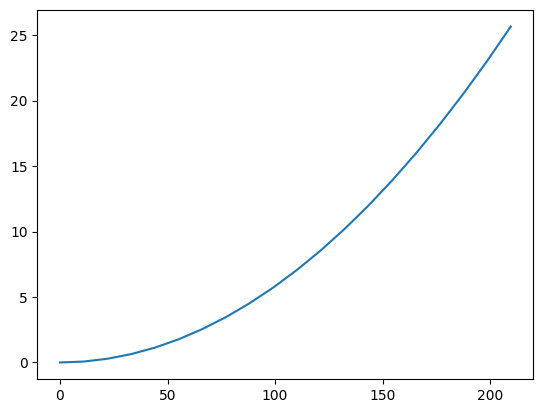

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)

    η = [x[-1],y[-1],z[-1],φ[-1],θ[-1],ψ[-1]]

    tau_force = np.array([-Fx_0,Fy_0,0,0,0,0])

    Z0 = tau_force[:3]    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T


    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,kp->ijp', Π(φ,θ,ψ), tau_force[3:].reshape(3,1))
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0.squeeze())
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################

    ans=np.concatenate([dx, ddx, dy, ddy, dz, ddz, dφ, ddφ, dθ, ddθ, dψ, ddψ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='df-sane')

In [83]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 6.224e+01  6.224e+01 ...  0.000e+00  0.000e+00]
       x: [ 1.058e+03  1.069e+03 ...  0.000e+00  0.000e+00]
     nit: 330
    nfev: 1000
  method: df-sane

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
# q0 = root_.x                                            # start from static solution

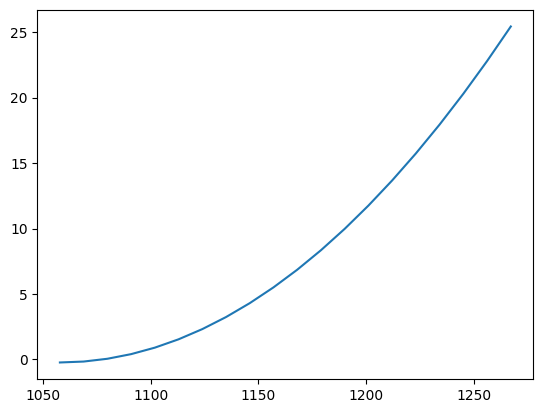

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Finite Element Model of the Space Frame Element

In [87]:
def PlaneTrussElementLength(x1,y1,z1,x2,y2,z2):
    return np.sqrt((x2-x1)*(x2-x1) + (y2-y1)*(y2-y1)+(z2-z1)*(z2-z1))

In [88]:
def SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,x1,y1,z1,x2,y2,z2):
    L = PlaneTrussElementLength(x1,y1,z1,x2,y2,z2)
    w1 = E*A/L
    w2 = 12*E*Iz/(L*L*L)
    w3 = 6*E*Iz/(L*L)
    w4 = 4*E*Iz/L
    w5 = 2*E*Iz/L
    w6 = 12*E*Iy/(L*L*L)
    w7 = 6*E*Iy/(L*L)
    w8 = 4*E*Iy/L
    w9 = 2*E*Iy/L
    w10 = G*J/L

    kprime = np.array([[w1, 0, 0, 0, 0, 0, -w1, 0, 0, 0, 0, 0],
                        [0, w2, 0, 0, 0, w3, 0, -w2, 0, 0, 0, w3],
                        [0, 0, w6, 0, -w7, 0, 0, 0, -w6, 0, -w7, 0],
                        [0, 0, 0, w10, 0, 0, 0, 0, 0, -w10, 0, 0],
                        [0, 0, -w7, 0, w8, 0, 0, 0, w7, 0, w9, 0],
                        [0, w3, 0, 0, 0, w4, 0, -w3, 0, 0, 0, w5],
                        [-w1, 0, 0, 0, 0, 0, w1, 0, 0, 0, 0, 0],
                        [0, -w2, 0, 0, 0, -w3, 0, w2, 0, 0, 0, -w3],
                        [0, 0, -w6, 0, w7, 0, 0, 0, w6, 0, w7, 0],
                        [0, 0, 0, -w10, 0, 0, 0, 0, 0, w10, 0, 0],
                        [0, 0, -w7, 0, w9, 0, 0, 0, w7, 0, w8, 0],
                        [0, w3, 0, 0, 0, w5, 0, -w3, 0, 0, 0, w4]])


    if x1 == x2 and y1 == y2:
        if z2 > z1:
            Lambda = np.array([[0, 0, 1], [0, 1, 0], [-1, 0, 0]])
        else:
            Lambda = np.array([[0, 0, -1], [0, 1, 0], [1, 0, 0]])
    else:
        CXx = (x2-x1)/L
        CYx = (y2-y1)/L
        CZx = (z2-z1)/L
        D = np.sqrt(CXx*CXx + CYx*CYx)
        CXy = -CYx/D
        CYy = CXx/D
        CZy = 0
        CXz = -CXx*CZx/D
        CYz = -CYx*CZx/D
        CZz = D
        Lambda = np.array([[CXx, CYx, CZx], [CXy, CYy, CZy], [CXz, CYz, CZz]])


    R = np.array([np.concatenate((np.concatenate((Lambda,np.zeros((3,3)),np.zeros((3,3)),np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), Lambda, np.zeros((3,3)), np.zeros((3,3))),axis=1) ,
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), Lambda, np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), np.zeros((3,3)), Lambda),axis=1)))])[0]
    return np.dot(np.dot(R.T,kprime),R)

In [89]:
def SpaceFrameAssemble(K,k,i,j):
    K[6*i,6*i] = K[6*i,6*i] + k[0,0]
    K[6*i,6*i+1] = K[6*i,6*i+1] + k[0,1]
    K[6*i,6*i+2] = K[6*i,6*i+2] + k[0,2]
    K[6*i,6*i+3] = K[6*i,6*i+3] + k[0,3]
    K[6*i,6*i+4] = K[6*i,6*i+4] + k[0,4]
    K[6*i,6*i+5] = K[6*i,6*i+5] + k[0,5]
    K[6*i,6*j] = K[6*i,6*j] + k[0,6]
    K[6*i,6*j+1] = K[6*i,6*j+1] + k[0,7]
    K[6*i,6*j+2] = K[6*i,6*j+2] + k[0,8]
    K[6*i,6*j+3] = K[6*i,6*j+3] + k[0,9]
    K[6*i,6*j+4] = K[6*i,6*j+4] + k[0,10]
    K[6*i,6*j+5] = K[6*i,6*j+5] + k[0,11]
    K[6*i+1,6*i] = K[6*i+1,6*i] + k[1,0]
    K[6*i+1,6*i+1] = K[6*i+1,6*i+1] + k[1,1]
    K[6*i+1,6*i+2] = K[6*i+1,6*i+2] + k[1,2]
    K[6*i+1,6*i+3] = K[6*i+1,6*i+3] + k[1,3]
    K[6*i+1,6*i+4] = K[6*i+1,6*i+4] + k[1,4]
    K[6*i+1,6*i+5] = K[6*i+1,6*i+5] + k[1,5]
    K[6*i+1,6*j] = K[6*i+1,6*j] + k[1,6]
    K[6*i+1,6*j+1] = K[6*i+1,6*j+1] + k[1,7]
    K[6*i+1,6*j+2] = K[6*i+1,6*j+2] + k[1,8]
    K[6*i+1,6*j+3] = K[6*i+1,6*j+3] + k[1,9]
    K[6*i+1,6*j+4] = K[6*i+1,6*j+4] + k[1,10]
    K[6*i+1,6*j+5] = K[6*i+1,6*j+5] + k[1,11]
    K[6*i+2,6*i]   = K[6*i+2,6*i] + k[2,0]
    K[6*i+2,6*i+1] = K[6*i+2,6*i+1] + k[2,1]
    K[6*i+2,6*i+2] = K[6*i+2,6*i+2] + k[2,2]
    K[6*i+2,6*i+3] = K[6*i+2,6*i+3] + k[2,3]
    K[6*i+2,6*i+4] = K[6*i+2,6*i+4] + k[2,4]
    K[6*i+2,6*i+5] = K[6*i+2,6*i+5] + k[2,5]
    K[6*i+2,6*j]   = K[6*i+2,6*j] + k[2,6]
    K[6*i+2,6*j+1] = K[6*i+2,6*j+1] + k[2,7]
    K[6*i+2,6*j+2] = K[6*i+2,6*j+2] + k[2,8]
    K[6*i+2,6*j+3] = K[6*i+2,6*j+3] + k[2,9]
    K[6*i+2,6*j+4] = K[6*i+2,6*j+4] + k[2,10]
    K[6*i+2,6*j+5] = K[6*i+2,6*j+5] + k[2,11]
    K[6*i+3,6*i] = K[6*i+3,6*i] + k[3,0]
    K[6*i+3,6*i+1] = K[6*i+3,6*i+1] + k[3,1]
    K[6*i+3,6*i+2] = K[6*i+3,6*i+2] + k[3,2]
    K[6*i+3,6*i+3] = K[6*i+3,6*i+3] + k[3,3]
    K[6*i+3,6*i+4] = K[6*i+3,6*i+4] + k[3,4]
    K[6*i+3,6*i+5] = K[6*i+3,6*i+5] + k[3,5]
    K[6*i+3,6*j] = K[6*i+3,6*j] + k[3,6]
    K[6*i+3,6*j+1] = K[6*i+3,6*j+1] + k[3,7]
    K[6*i+3,6*j+2] = K[6*i+3,6*j+2] + k[3,8]
    K[6*i+3,6*j+3] = K[6*i+3,6*j+3] + k[3,9]
    K[6*i+3,6*j+4] = K[6*i+3,6*j+4] + k[3,10]
    K[6*i+3,6*j+5] = K[6*i+3,6*j+5] + k[3,11]
    K[6*i+4,6*i] = K[6*i+4,6*i] + k[4,0]
    K[6*i+4,6*i+1] = K[6*i+4,6*i+1] + k[4,1]
    K[6*i+4,6*i+2] = K[6*i+4,6*i+2] + k[4,2]
    K[6*i+4,6*i+3] = K[6*i+4,6*i+3] + k[4,3]
    K[6*i+4,6*i+4] = K[6*i+4,6*i+4] + k[4,4]
    K[6*i+4,6*i+5] = K[6*i+4,6*i+5] + k[4,5]
    K[6*i+4,6*j] = K[6*i+4,6*j] + k[4,6]
    K[6*i+4,6*j+1] = K[6*i+4,6*j+1] + k[4,7]
    K[6*i+4,6*j+2] = K[6*i+4,6*j+2] + k[4,8]
    K[6*i+4,6*j+3] = K[6*i+4,6*j+3] + k[4,9]
    K[6*i+4,6*j+4] = K[6*i+4,6*j+4] + k[4,10]
    K[6*i+4,6*j+5] = K[6*i+4,6*j+5] + k[4,11]
    K[6*i+5,6*i] = K[6*i+5,6*i] + k[5,0]
    K[6*i+5,6*i+1] = K[6*i+5,6*i+1] + k[5,1]
    K[6*i+5,6*i+2] = K[6*i+5,6*i+2] + k[5,2]
    K[6*i+5,6*i+3] = K[6*i+5,6*i+3] + k[5,3]
    K[6*i+5,6*i+4] = K[6*i+5,6*i+4] + k[5,4]
    K[6*i+5,6*i+5] = K[6*i+5,6*i+5] + k[5,5]
    K[6*i+5,6*j] = K[6*i+5,6*j] + k[5,6]
    K[6*i+5,6*j+1] = K[6*i+5,6*j+1] + k[5,7]
    K[6*i+5,6*j+2] = K[6*i+5,6*j+2] + k[5,8]
    K[6*i+5,6*j+3] = K[6*i+5,6*j+3] + k[5,9]
    K[6*i+5,6*j+4] = K[6*i+5,6*j+4] + k[5,10]
    K[6*i+5,6*j+5] = K[6*i+5,6*j+5] + k[5,11]
    K[6*j,6*i] = K[6*j,6*i] + k[6,0]
    K[6*j,6*i+1] = K[6*j,6*i+1] + k[6,1]
    K[6*j,6*i+2] = K[6*j,6*i+2] + k[6,2]
    K[6*j,6*i+3] = K[6*j,6*i+3] + k[6,3]
    K[6*j,6*i+4] = K[6*j,6*i+4] + k[6,4]
    K[6*j,6*i+5] = K[6*j,6*i+5] + k[6,5]
    K[6*j,6*j] = K[6*j,6*j] + k[6,6]
    K[6*j,6*j+1] = K[6*j,6*j+1] + k[6,7]
    K[6*j,6*j+2] = K[6*j,6*j+2] + k[6,8]
    K[6*j,6*j+3] = K[6*j,6*j+3] + k[6,9]
    K[6*j,6*j+4] = K[6*j,6*j+4] + k[6,10]
    K[6*j,6*j+5] = K[6*j,6*j+5] + k[6,11]
    K[6*j+1,6*i] = K[6*j+1,6*i] + k[7,0]
    K[6*j+1,6*i+1] = K[6*j+1,6*i+1] + k[7,1]
    K[6*j+1,6*i+2] = K[6*j+1,6*i+2] + k[7,2]
    K[6*j+1,6*i+3] = K[6*j+1,6*i+3] + k[7,3]
    K[6*j+1,6*i+4] = K[6*j+1,6*i+4] + k[7,4]
    K[6*j+1,6*i+5] = K[6*j+1,6*i+5] + k[7,5]
    K[6*j+1,6*j] = K[6*j+1,6*j] + k[7,6]
    K[6*j+1,6*j+1] = K[6*j+1,6*j+1] + k[7,7]
    K[6*j+1,6*j+2] = K[6*j+1,6*j+2] + k[7,8]
    K[6*j+1,6*j+3] = K[6*j+1,6*j+3] + k[7,9]
    K[6*j+1,6*j+4] = K[6*j+1,6*j+4] + k[7,10]
    K[6*j+1,6*j+5] = K[6*j+1,6*j+5] + k[7,11]
    K[6*j+2,6*i] = K[6*j+2,6*i] + k[8,0]
    K[6*j+2,6*i+1] = K[6*j+2,6*i+1] + k[8,1]
    K[6*j+2,6*i+2] = K[6*j+2,6*i+2] + k[8,2]
    K[6*j+2,6*i+3] = K[6*j+2,6*i+3] + k[8,3]
    K[6*j+2,6*i+4] = K[6*j+2,6*i+4] + k[8,4]
    K[6*j+2,6*i+5] = K[6*j+2,6*i+5] + k[8,5]
    K[6*j+2,6*j] = K[6*j+2,6*j] + k[8,6]
    K[6*j+2,6*j+1] = K[6*j+2,6*j+1] + k[8,7]
    K[6*j+2,6*j+2] = K[6*j+2,6*j+2] + k[8,8]
    K[6*j+2,6*j+3] = K[6*j+2,6*j+3] + k[8,9]
    K[6*j+2,6*j+4] = K[6*j+2,6*j+4] + k[8,10]
    K[6*j+2,6*j+5] = K[6*j+2,6*j+5] + k[8,11]
    K[6*j+3,6*i] = K[6*j+3,6*i] + k[9,0]
    K[6*j+3,6*i+1] = K[6*j+3,6*i+1] + k[9,1]
    K[6*j+3,6*i+2] = K[6*j+3,6*i+2] + k[9,2]
    K[6*j+3,6*i+3] = K[6*j+3,6*i+3] + k[9,3]
    K[6*j+3,6*i+4] = K[6*j+3,6*i+4] + k[9,4]
    K[6*j+3,6*i+5] = K[6*j+3,6*i+5] + k[9,5]
    K[6*j+3,6*j] = K[6*j+3,6*j] + k[9,6]
    K[6*j+3,6*j+1] = K[6*j+3,6*j+1] + k[9,7]
    K[6*j+3,6*j+2] = K[6*j+3,6*j+2] + k[9,8]
    K[6*j+3,6*j+3] = K[6*j+3,6*j+3] + k[9,9]
    K[6*j+3,6*j+4] = K[6*j+3,6*j+4] + k[9,10]
    K[6*j+3,6*j+5] = K[6*j+3,6*j+5] + k[9,11]
    K[6*j+4,6*i] = K[6*j+4,6*i] + k[10,0]
    K[6*j+4,6*i+1] = K[6*j+4,6*i+1] + k[10,1]
    K[6*j+4,6*i+2] = K[6*j+4,6*i+2] + k[10,2]
    K[6*j+4,6*i+3] = K[6*j+4,6*i+3] + k[10,3]
    K[6*j+4,6*i+4] = K[6*j+4,6*i+4] + k[10,4]
    K[6*j+4,6*i+5] = K[6*j+4,6*i+5] + k[10,5]
    K[6*j+4,6*j] = K[6*j+4,6*j] + k[10,6]
    K[6*j+4,6*j+1] = K[6*j+4,6*j+1] + k[10,7]
    K[6*j+4,6*j+2] = K[6*j+4,6*j+2] + k[10,8]
    K[6*j+4,6*j+3] = K[6*j+4,6*j+3] + k[10,9]
    K[6*j+4,6*j+4] = K[6*j+4,6*j+4] + k[10,10]
    K[6*j+4,6*j+5] = K[6*j+4,6*j+5] + k[10,11]
    K[6*j+5,6*i] = K[6*j+5,6*i] + k[11,0]
    K[6*j+5,6*i+1] = K[6*j+5,6*i+1] + k[11,1]
    K[6*j+5,6*i+2] = K[6*j+5,6*i+2] + k[11,2]
    K[6*j+5,6*i+3] = K[6*j+5,6*i+3] + k[11,3]
    K[6*j+5,6*i+4] = K[6*j+5,6*i+4] + k[11,4]
    K[6*j+5,6*i+5] = K[6*j+5,6*i+5] + k[11,5]
    K[6*j+5,6*j] = K[6*j+5,6*j] + k[11,6]
    K[6*j+5,6*j+1] = K[6*j+5,6*j+1] + k[11,7]
    K[6*j+5,6*j+2] = K[6*j+5,6*j+2] + k[11,8]
    K[6*j+5,6*j+3] = K[6*j+5,6*j+3] + k[11,9]
    K[6*j+5,6*j+4] = K[6*j+5,6*j+4] + k[11,10]
    K[6*j+5,6*j+5] = K[6*j+5,6*j+5] + k[11,11]

    return K

In [90]:
def FEA(coord, elcon, bc_node, bc_val, vessel_movement, coefs,
          E=210e6, G=84e6, A=2e-2, Iy=10e-5, Iz=20e-5, J=5e-5):

    coord=np.array(coord)
    elcon=np.array(elcon)

    K=np.zeros(shape=(6*(np.max(elcon)+1),6*(np.max(elcon)+1)))

    for el in elcon:
        k=SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,
                                     coord[el[0]][0],coord[el[0]][1],coord[el[0]][2],\
                                     coord[el[1]][0],coord[el[1]][1],coord[el[1]][2])
        K=SpaceFrameAssemble(K,k,el[0],el[1])
        
        
    glob_force=np.dot(K, np.array(vessel_movement))
    
    glob_force[-6:]=np.multiply(glob_force[-6:], coefs)
    glob_force = np.zeros(len(vessel_movement))


    F=np.zeros(len(coord)*6)
    for i in range(len(vessel_movement)):
        if vessel_movement[i]:
            F[i]=glob_force[i]

    # https://github.com/CALFEM/calfem-matlab/blob/master/fem/solveq.m

    bc=np.array([bc_node,
                bc_val]).T
    nd, nd=K.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    s=scipy.linalg.lstsq(K[fdof,:][:,fdof], (F[fdof].T-np.dot(K[fdof,:][:,pdof],dp.T)).T, check_finite=True)[0]
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
    

#     Q=np.dot(K,d).T-F
    return d, np.dot(K,d).T

In [91]:
# 10 The Space Frame Element - verification
d,f=FEA(np.array([0,0,0,
                  3,0,0,
                  0,0,-3,
                  0,-4,0]).reshape(4,3),
        elcon=np.array([[0, 1],
                      [0, 2],
                      [0, 3]]),
        bc_node=list(range(6)),
        bc_val=[ -0.0705e-4, -0.0007e-4, 0.1418e-4, 0.0145e-4, 0.0175e-4,0.0114e-4],
        vessel_movement=[ 0, 0, 0, 0, 0,0.0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                       ],
        coefs=[1,1,1,1,1,1])

In [92]:
d

array([-7.050e-06, -7.000e-08,  1.418e-05,  1.450e-06,  1.750e-06,
        1.140e-06, -7.050e-06,  3.350e-06,  8.930e-06,  1.450e-06,
        1.750e-06,  1.140e-06, -1.230e-05,  4.280e-06,  1.418e-05,
        1.450e-06,  1.750e-06,  1.140e-06, -2.490e-06, -7.000e-08,
        8.380e-06,  1.450e-06,  1.750e-06,  1.140e-06])

In [93]:
f

array([ 2.18575158e-15, -1.86923231e-17, -3.84067778e-15,  9.71445147e-17,
        4.94078553e-17, -1.38777878e-17, -5.59719372e-16, -2.94360890e-17,
        2.29749217e-17,  3.06625927e-19,  2.51331616e-17,  5.88721780e-17,
        1.93123512e-17,  1.42708111e-17,  1.72398987e-15, -2.85416222e-17,
        6.63802780e-17, -6.09863722e-20,  2.08166817e-17,  4.64478987e-17,
        2.42861287e-17,  1.38777878e-17,  3.17637355e-20, -1.38777878e-17])

In [94]:
def PipeForce(X,Y,Z,vessel_movement,coefs, E=E, G=G, A=Ar, Iy=Iy_, Iz=Iz_, J=J_):
    coord=np.stack((X,Y,Z)).T
    elcon=[]
    for i in range(1,len(X)):
        elcon.append([i-1,i])
    
    bc_node = list(range(3))+list(range((6*len(X)-6),6*len(X)))
    bc_val = [0]*3 + vessel_movement
    
    vessel_move=np.zeros(len(X)*6)

    d, f = FEA(coord,elcon,bc_node,bc_val,vessel_move, coefs, E,G,A,Iy,Iz,J)

    fors=[]
    for i in range(0,len(f),6):
        fors.append(f[i:i+3])

    mom =[]
    for i in range(3,len(f),6):
        mom.append(f[i:i+3])

    angle=[]
    for i in range(3,len(d),6):
        angle.append(d[i:i+3])
    fors[0][0]=0
    fors[0][1]=0
    fors[0][2]=0
    return np.array(fors), np.array(mom), np.array(angle)

In [95]:
fors, mom, angle = PipeForce(x0_,list([0 for i in range(len(z0))]),z0_,
[0.01,
 0.02,
 0.03,
 0.01,
 -0.05,
 0.03],
 [1,1,1,1,1,1]
)

In [96]:
fors

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 8.68445262e-04,  2.36511230e-04,  1.01947784e-03],
       [ 8.10623169e-05,  9.15527344e-05,  1.26266479e-03],
       [ 3.67760658e-04,  9.31739807e-04, -2.23922729e-03],
       [-7.35759735e-04,  3.96728516e-04,  2.52056122e-03],
       [ 2.20775604e-04, -1.52587891e-04, -2.39181519e-03],
       [ 2.51770020e-04, -5.87463379e-04,  2.62451172e-03],
       [ 5.81264496e-04, -5.96046448e-04, -2.12478638e-03],
       [ 1.38878822e-04, -1.11389160e-03,  1.06978416e-03],
       [ 2.15768814e-04, -7.62939453e-04, -1.52587891e-04],
       [ 7.34329224e-05, -1.52587891e-05, -9.07897949e-04],
       [-5.61714172e-04,  1.83105469e-04,  1.94549561e-03],
       [ 2.85625458e-04,  5.79833984e-04, -3.08918953e-03],
       [-6.51359558e-04,  1.35803223e-03,  3.93295288e-03],
       [ 1.02615356e-03,  4.73022461e-04, -4.44030762e-03],
       [-7.08239670e-04, -6.31462020e-04,  4.73650431e-03],
       [ 9.13667675e-04, -1.04998236e-03

In [97]:
mom

array([[ 3.57627869e-04,  1.85958482e-03, -3.05175781e-05],
       [-1.12295151e-04,  1.75476074e-04,  6.39915466e-04],
       [-3.50713730e-04, -2.67028809e-04,  2.44140625e-04],
       [-4.38690186e-04, -1.06811523e-04,  5.64575195e-04],
       [-7.01904297e-04,  2.17437744e-04,  2.44140625e-04],
       [-7.86781311e-05, -2.31933594e-03, -2.17437744e-04],
       [ 2.55584717e-04, -6.13212585e-04,  6.10351562e-05],
       [ 4.63485718e-04, -1.70898438e-03, -4.73022461e-04],
       [ 1.67846680e-04,  1.89304352e-04,  7.93457031e-04],
       [ 2.96592712e-04, -7.32421875e-04,  6.29425049e-04],
       [ 0.00000000e+00,  6.00814819e-05,  1.22070312e-04],
       [-2.76565552e-04,  1.58691406e-03,  4.57763672e-04],
       [-1.67846680e-04, -1.20162964e-04, -1.09863281e-03],
       [-6.77108765e-05, -1.83105469e-04, -1.21307373e-03],
       [-1.06811523e-04, -3.41892242e-04, -4.88281250e-04],
       [ 2.04202501e-04,  8.63075520e-04,  1.22712364e-04],
       [-1.28896868e-04, -5.14287287e-04

In [98]:
angle

array([[-0.37716846,  0.01905929, -0.04143285],
       [-0.37716847,  0.01898777, -0.0414322 ],
       [-0.37682588,  0.01875328, -0.04142365],
       [-0.37579827,  0.01831588, -0.04138742],
       [-0.37374356,  0.01763548, -0.04129054],
       [-0.37032016,  0.01667179, -0.04108688],
       [-0.36518718,  0.01538427, -0.04071713],
       [-0.35800453,  0.01373209, -0.04010885],
       [-0.34843317,  0.0116741 , -0.03917646],
       [-0.33613518,  0.00916875, -0.0378213 ],
       [-0.32077401,  0.00617405, -0.03593161],
       [-0.30201456,  0.00264755, -0.03338259],
       [-0.27952338, -0.00145373, -0.03003643],
       [-0.25296882, -0.00617336, -0.02574232],
       [-0.22202116, -0.0115555 , -0.02033652],
       [-0.18635277, -0.01764501, -0.01364238],
       [-0.14563825, -0.02448746, -0.00547038],
       [-0.09955454, -0.0321292 ,  0.00438182],
       [-0.0477811 , -0.04061736,  0.01612933],
       [ 0.01      , -0.05      ,  0.03      ]])

### Vessle Simulation

In [99]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [100]:
Number*sampleTime

600.0

In [101]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [102]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [103]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

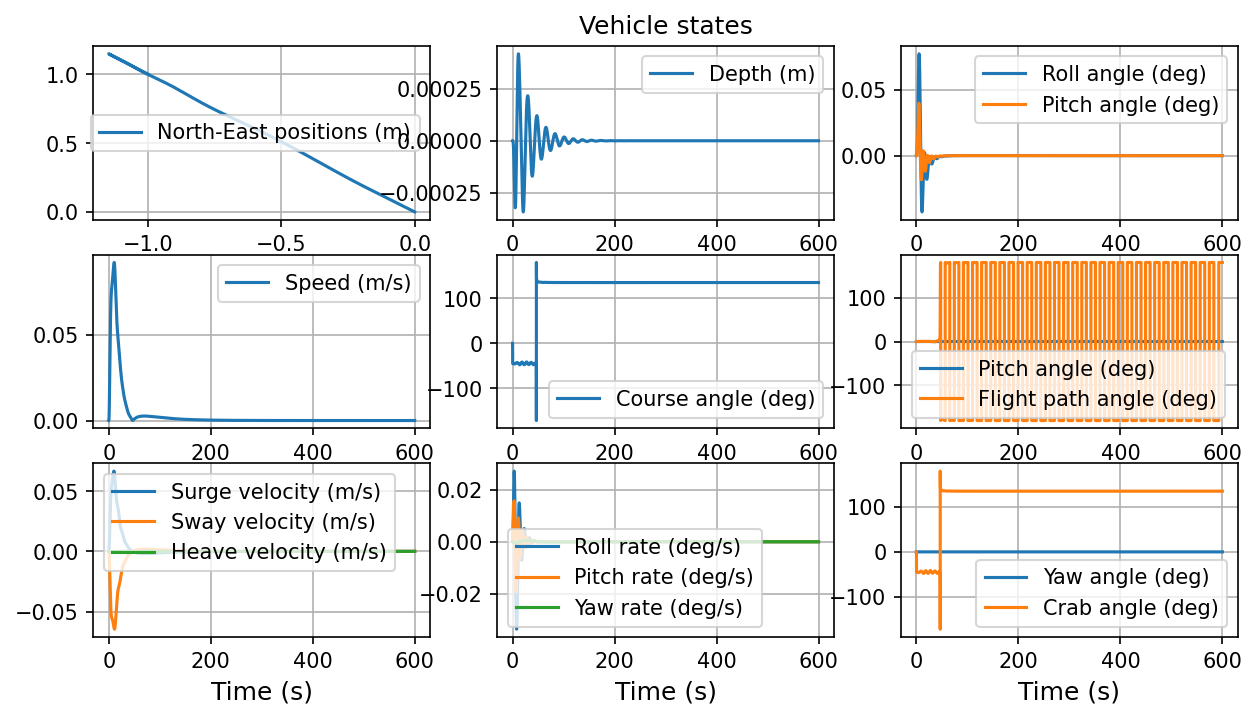

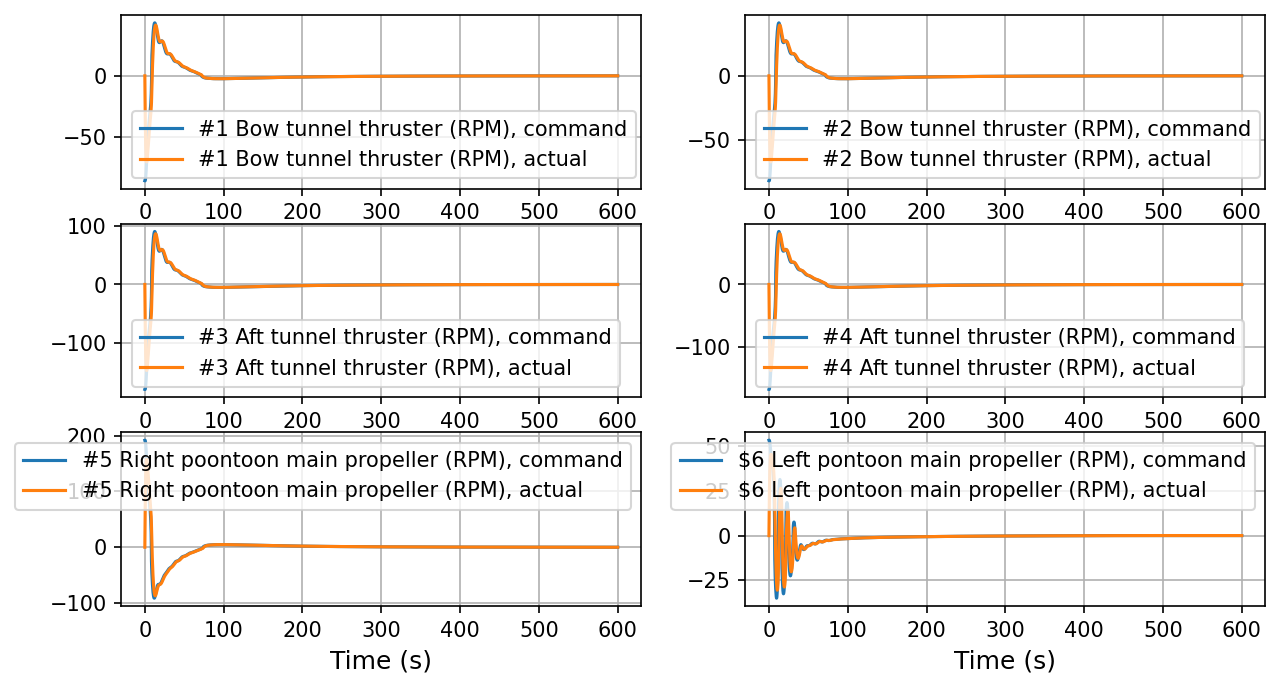

In [104]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [105]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

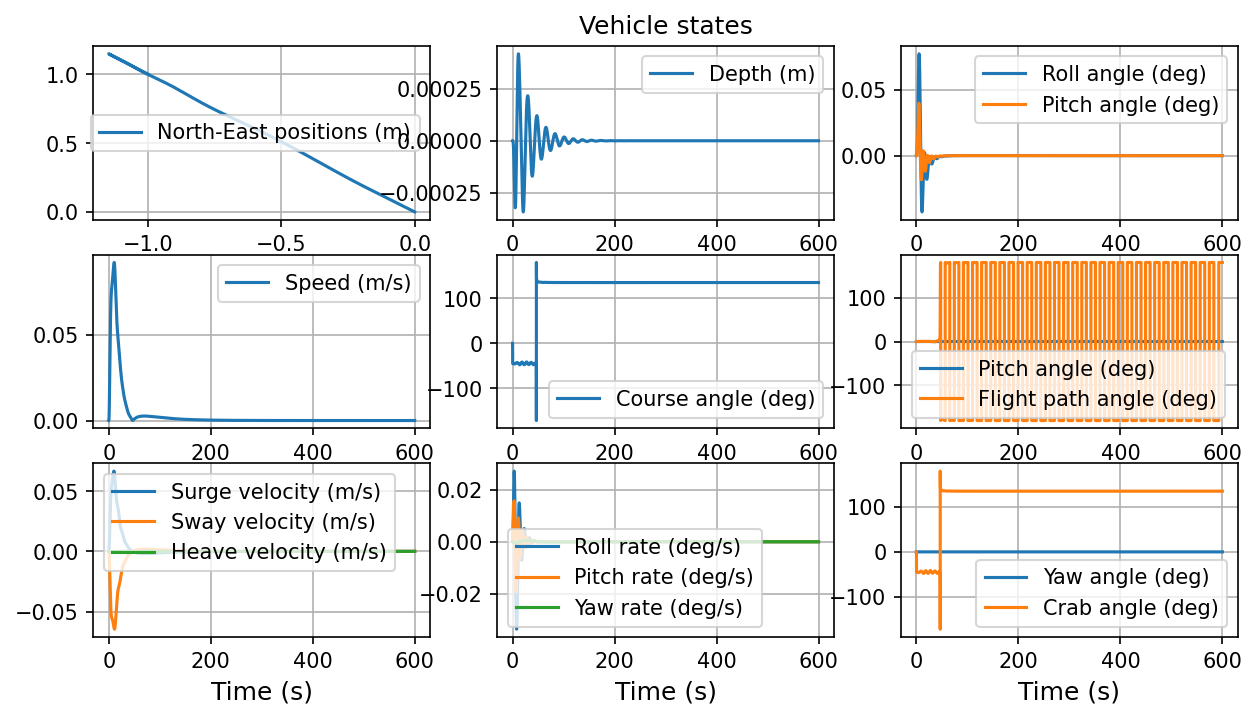

In [106]:
plotVehicleStates(simTime, simData, 3)

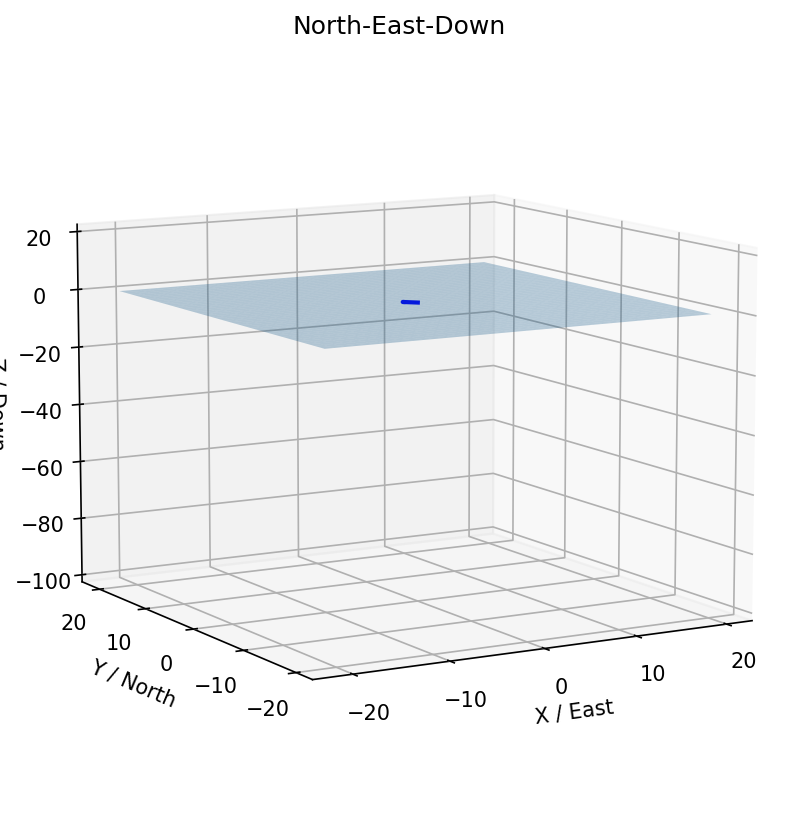

In [107]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [108]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [109]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamics

In [110]:
def dynamic_func(t, Q, coefs, T, calibr):
    
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    del_t = idx-T.my_t
    if del_t<0:
        idx=T.my_t
        
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = ssa(simData[:, 3][idx])
    theta_ve = ssa(simData[:, 4][idx])
    psi_ve = ssa(simData[:, 5][idx])
    
    RET = Ret(φ,θ,ψ)

    vessel_movement = np.zeros(6)
    
    
    vessel_movement[0] = (x_ve - T.x_ve)
    vessel_movement[1] = (y_ve - T.y_ve)
    vessel_movement[2] = (z_ve - T.z_ve)
    vessel_movement[3] = (phi_ve - T.phi_ve)
    vessel_movement[4] = (theta_ve - T.theta_ve)
    vessel_movement[5] = (psi_ve - T.psi_ve)

    vessel_movement/=calibr
    

    fors, mom, angle = PipeForce(x, y, z, list(vessel_movement), coefs)
    
    Z0 = fors.squeeze()
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T

    Z = (Z1 + Z2 - 0*Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,ik->ij', Π(φ,θ,ψ), angle).squeeze()    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - 0*C0)

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################

    T.my_t=idx
    T.x_ve=x_ve
    T.y_ve=y_ve
    T.z_ve=z_ve
    T.phi_ve = phi_ve
    T.theta_ve = theta_ve
    T.psi_ve = psi_ve

    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy, 
                        dz, ddz, 
                        dφ, ddφ, 
                        dθ, ddθ, 
                        dψ, ddψ
                       ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
    return ans

In [111]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.000001 for i in range(N)]),
                                          np.array([0.001257*i/N for i in range(N)]))

In [112]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,))
print(datetime.now() - startTime1)

Physical time:  9.84646067382047e-08  Iteration wall-clock time:  0:00:00.535635
Physical time:  1.0110745136654047  Iteration wall-clock time:  0:00:55.965570
Physical time:  2.0002638611715966  Iteration wall-clock time:  0:00:59.986637
Physical time:  3.0189705444277295  Iteration wall-clock time:  0:00:57.644073
Physical time:  4.002363754341488  Iteration wall-clock time:  0:00:57.961535
Physical time:  5.01948767287423  Iteration wall-clock time:  0:01:01.454678
Physical time:  6.006864086091461  Iteration wall-clock time:  0:00:58.546481
Physical time:  7.023125841750273  Iteration wall-clock time:  0:00:59.885810
Physical time:  8.007809796333751  Iteration wall-clock time:  0:00:52.352938
Physical time:  9.001623404798295  Iteration wall-clock time:  0:00:56.913526
Physical time:  10.015642755417804  Iteration wall-clock time:  0:00:50.540296
Physical time:  11.002967572258285  Iteration wall-clock time:  0:00:57.248307
0:11:19.457027


In [113]:
# max axial tension
T_.top_tension

388509.55751501216

In [114]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.00012568038909609028

### Results

In [115]:
fin=us_

In [116]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.846e-06 ...  1.199e+01  1.200e+01]
        y: [[ 0.000e+00  3.337e-25 ...  1.100e-04  1.102e-04]
            [ 1.103e+01  1.103e+01 ...  1.053e+01  1.053e+01]
            ...
            [ 0.000e+00 -3.441e-20 ...  2.280e-16  2.278e-16]
            [ 0.000e+00 -3.676e-21 ...  3.197e-17  3.161e-17]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1898
     njev: 0
      nlu: 0

In [117]:
t=fin.t

In [118]:
fin=fin.y.T

In [119]:
t.shape, fin.shape

((253,), (253, 240))

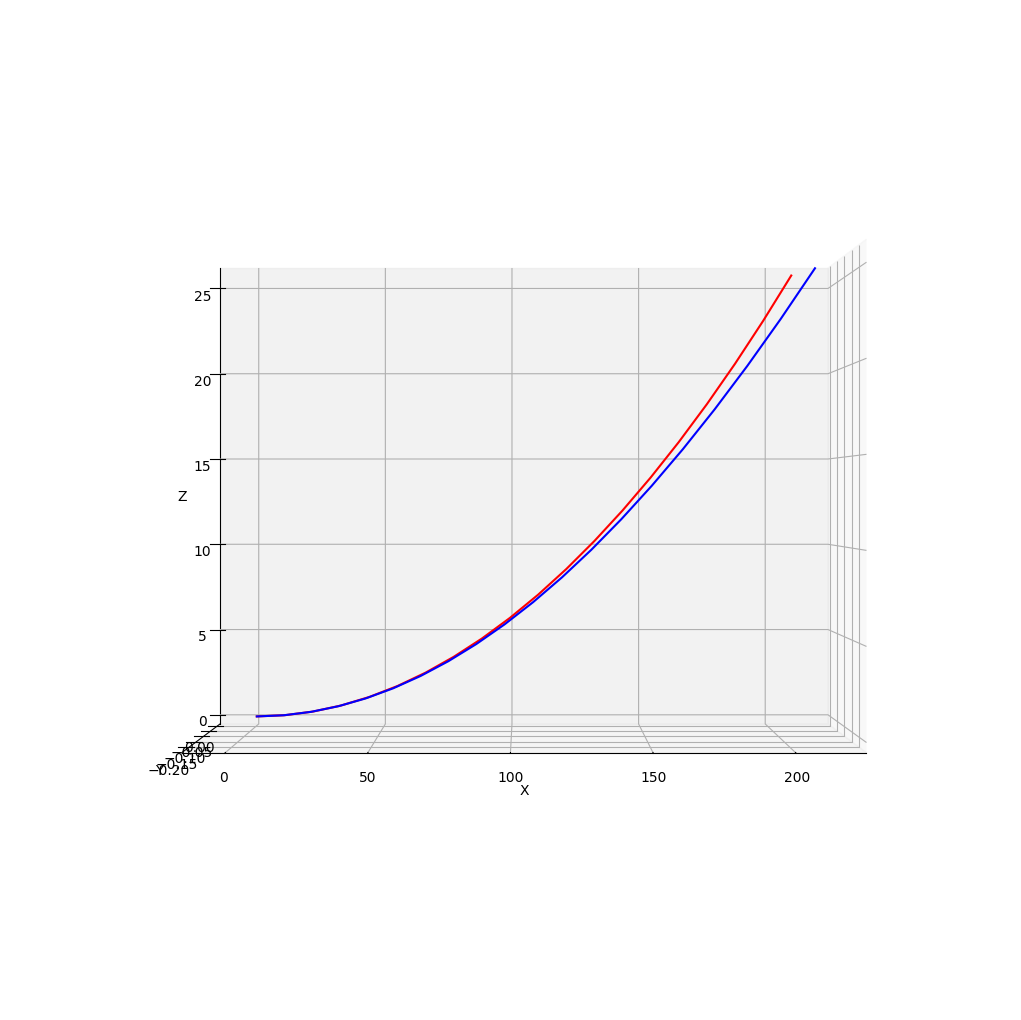

In [120]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [121]:
X,Y,Z

(array([1.10238295e-04, 1.05335776e+01, 2.12410150e+01, 3.20178380e+01,
        4.28346431e+01, 5.36793899e+01, 6.45465298e+01, 7.54337039e+01,
        8.63403842e+01, 9.72673265e+01, 1.08216114e+02, 1.19188594e+02,
        1.30186372e+02, 1.41209466e+02, 1.52255208e+02, 1.63315201e+02,
        1.74380390e+02, 1.85444730e+02, 1.96505287e+02, 2.07560591e+02]),
 array([ 1.10235930e-08,  2.18952285e-04, -3.92983160e-04, -2.35265212e-03,
        -5.79030062e-03, -1.06873034e-02, -1.70170767e-02, -2.47639661e-02,
        -3.39205292e-02, -4.44843663e-02, -5.64560179e-02, -6.98378360e-02,
        -8.46330010e-02, -1.00843926e-01, -1.18470601e-01, -1.37507354e-01,
        -1.57946281e-01, -1.79779289e-01, -2.02995698e-01, -2.27584212e-01]),
 array([-1.32727969e-03,  6.52082447e-02,  2.66522452e-01,  6.03491882e-01,
         1.07673010e+00,  1.68669773e+00,  2.43375528e+00,  3.31823953e+00,
         4.34050918e+00,  5.50097758e+00,  6.80012725e+00,  8.23849781e+00,
         9.81665700e+00,  1.

In [122]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [123]:
us=fin.T

In [124]:
us.shape

(240, 253)

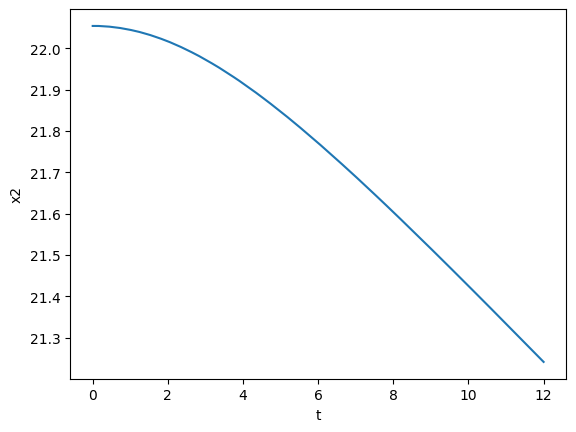

In [125]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

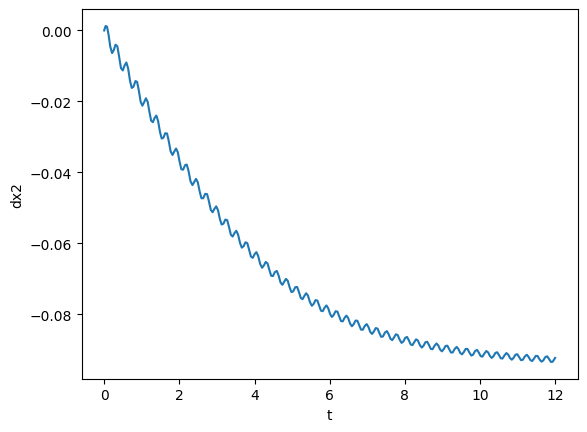

In [126]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

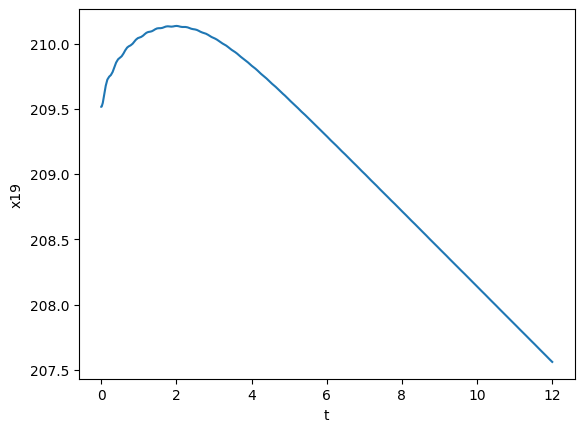

In [127]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

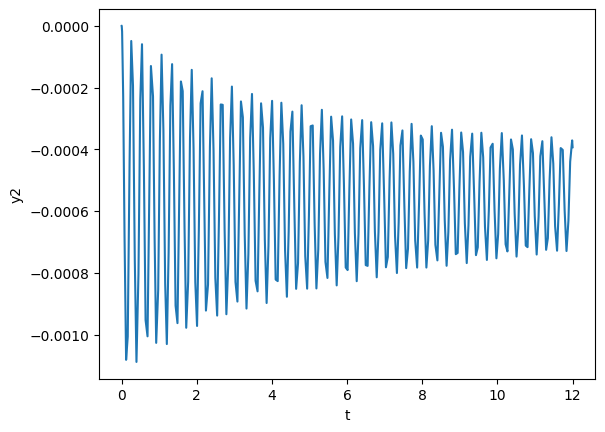

In [128]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

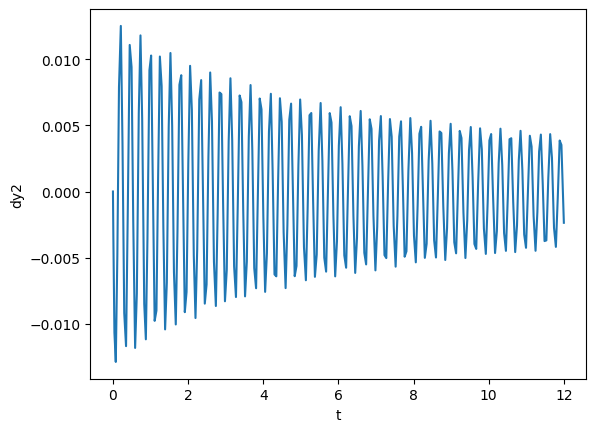

In [129]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

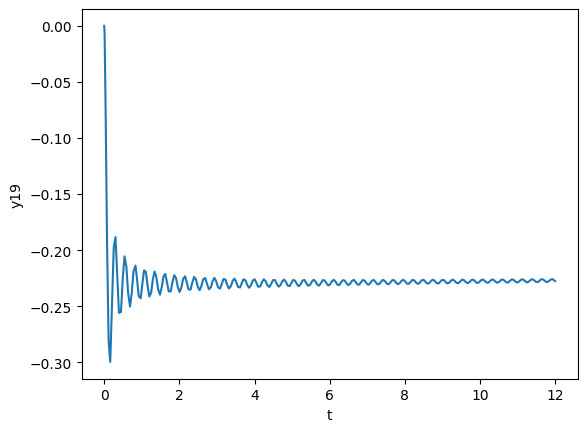

In [130]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

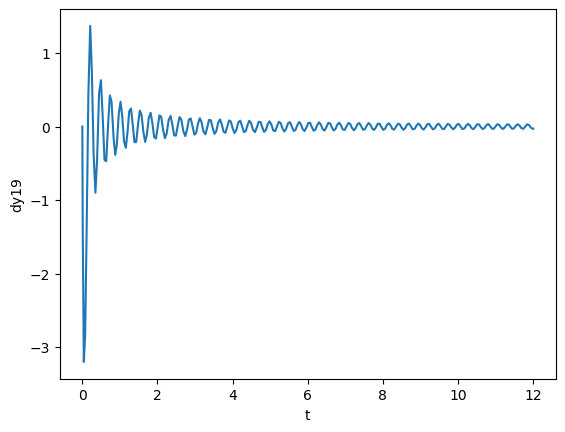

In [131]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

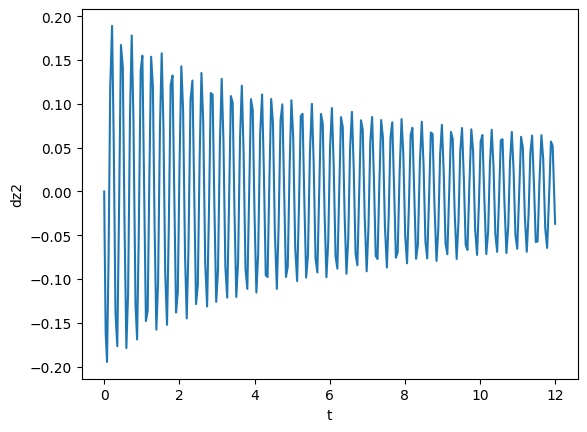

In [132]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

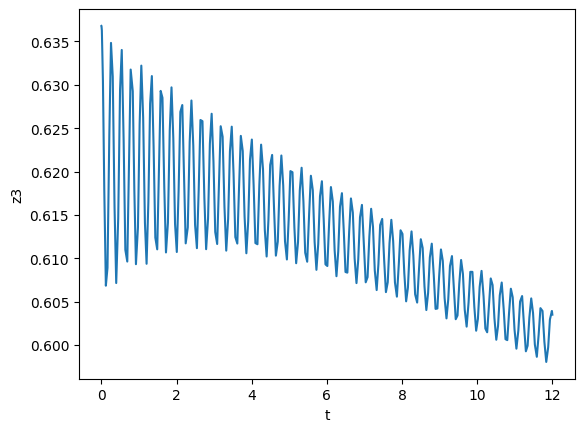

In [133]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

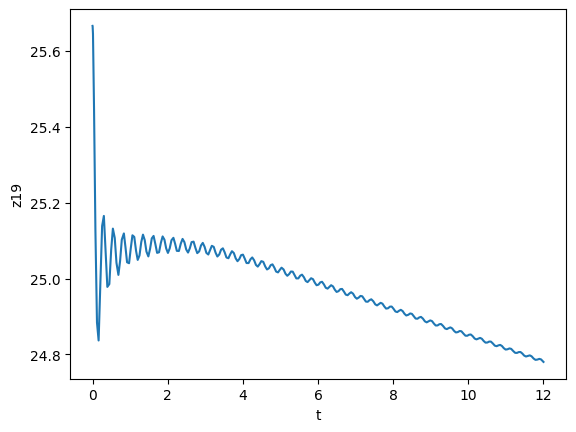

In [134]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

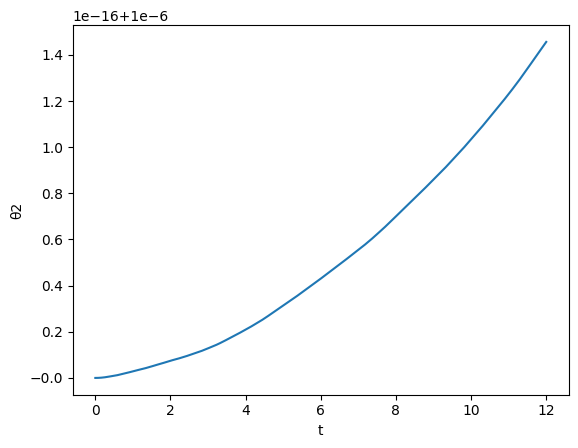

In [135]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

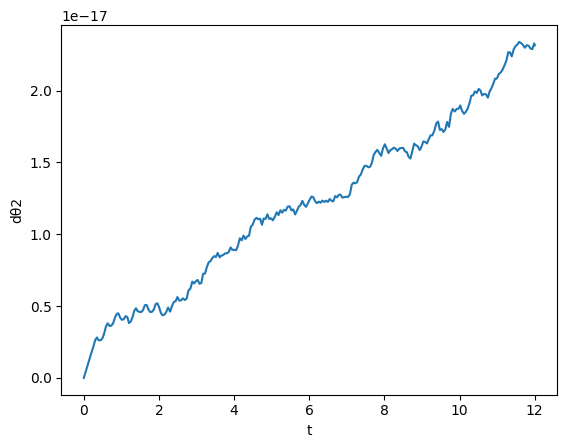

In [136]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

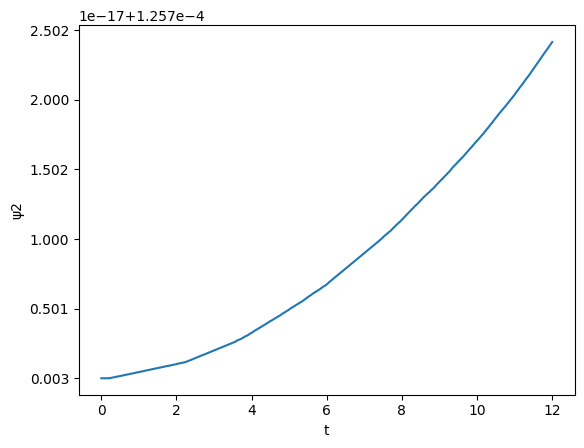

In [137]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

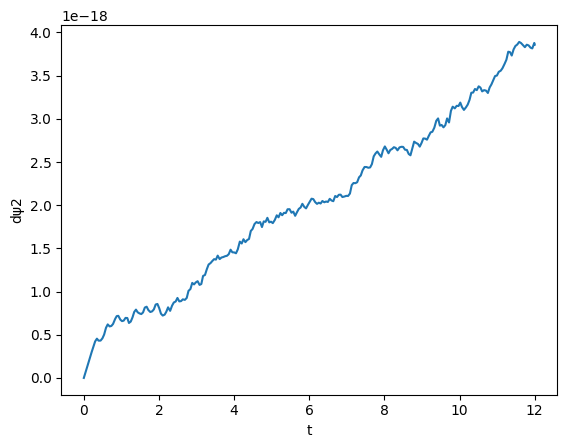

In [138]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

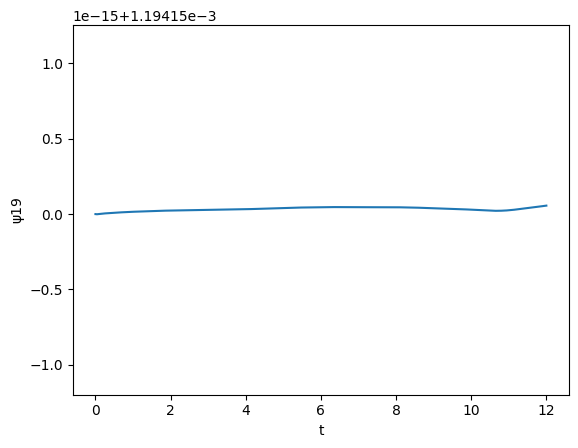

In [139]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [140]:
X010=us.T[:,0*N:1*N]

In [141]:
Y010=us.T[:,2*N:3*N]

In [142]:
Z010=us.T[:,4*N:5*N]

In [143]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 30                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 300]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 40]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()